In [1]:
!pip install langchain langchain_core langgraph langchain_community langchain_groq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.2/153.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.4/131.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.6/50.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.5/216.5 kB 7.8 MB/s eta 0:00:00


In [2]:

from typing import TypedDict, Dict
from langgraph.graph import StateGraph, END
from langchain.prompts import ChatPromptTemplate
import music21
import tempfile
import random

In [3]:
class MusicState(TypedDict):
  musician_input: str
  melody: str
  harmony: str
  rhythm: str
  style: str
  composition: str
  midi_file: str

In [4]:

from langchain_groq import ChatGroq

llm = ChatGroq(
    temperature = 0,
    groq_api_key = "",
    model_name = "llama-3.3-70b-versatile"
)

result = llm.invoke("What is ai?")

In [5]:

result.content

'**Artificial Intelligence (AI)**: AI refers to the development of computer systems that can perform tasks that typically require human intelligence, such as:\n\n* Learning\n* Problem-solving\n* Reasoning\n* Perception\n* Understanding language\n\nAI involves the use of algorithms, statistical models, and computer programs to enable machines to make decisions, classify data, and generate insights without human intervention.\n\n**Key Characteristics of AI:**\n\n1. **Machine Learning**: AI systems can learn from data and improve their performance over time.\n2. **Autonomy**: AI systems can operate independently, making decisions without human input.\n3. **Adaptability**: AI systems can adapt to new situations and learn from experience.\n4. **Reasoning**: AI systems can draw inferences, make decisions, and solve problems using logical rules and patterns.\n\n**Types of AI:**\n\n1. **Narrow or Weak AI**: Designed to perform a specific task, such as image recognition or language translation.

In [6]:
def melody_generator(state: MusicState) -> Dict:
  prompt = ChatPromptTemplate.from_template(
      "Generate a melody based on this input: {input}. Represent it as a string of notes in music21 format"
  )
  chain = prompt | llm
  melody = chain.invoke({"input": state["musician_input"]})
  return {"melody":melody.content}

def harmony_creator(state: MusicState) -> Dict:
  prompt = ChatPromptTemplate.from_template(
      "Create harmony for this melody: {melody}. Represent it as a string of chords in music21 format"
  )
  chain = prompt | llm
  harmony = chain.invoke({"melody": state["melody"]})
  return {"harmony":harmony.content}

def rhythm_analyzer(state: MusicState) -> Dict:
  prompt = ChatPromptTemplate.from_template(
      "Analyze and suggest a rhythm for this melody and harmony: {melody},{harmony}. Represent it as a string of duration in music21 format"
  )
  chain = prompt | llm
  rhythm = chain.invoke({"melody": state["melody"], "harmony": state["harmony"]})
  return {"rhythm":rhythm.content}

def style_adapter(state: MusicState)->Dict:
  prompt = ChatPromptTemplate.from_template(
      "Adapt this composition to the {style} style: Melody: {melody}, Harmony: {harmony}, Rhythm: {rhythm}. Provide the result in music21 format"
  )
  chain = prompt | llm
  adapted = chain.invoke(
      {
          "style": state["style"],
          "melody" : state["melody"],
          "harmony":state["harmony"],
          "rhythm":state["rhythm"]
      }
  )
  return {"composition": adapted.content}


In [9]:
workflow = StateGraph(MusicState)

workflow.add_node("melody_generator", melody_generator)
workflow.add_node("harmony_creator", harmony_creator)
workflow.add_node("rhythm_analyzer", rhythm_analyzer)
workflow.add_node("style_adapter", style_adapter)
workflow.add_node("midi_converter", midi_converter)

workflow.set_entry_point("melody_generator")

workflow.add_edge("melody_generator", "harmony_creator")
workflow.add_edge("harmony_creator", "rhythm_analyzer")
workflow.add_edge("rhythm_analyzer", "style_adapter")
workflow.add_edge("style_adapter", "midi_converter")
workflow.add_edge("midi_converter", END)

app = workflow.compile()

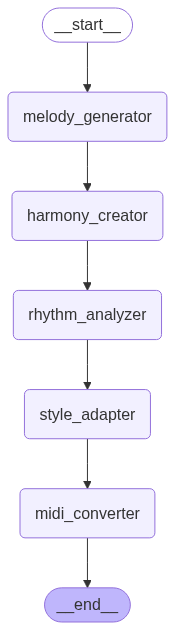

In [10]:
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display, Image

display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [11]:
inputs = {
    "musician_input": "Write a sorrowful string quartet in C minor",
    "style": "Romantic era"

}

result = app.invoke(inputs)
print(f"MIDI File saved in {result['midi_file']}")


MIDI File saved in /tmp/tmptji9boc8.mid


In [12]:

!apt install fluidsynth
!cp /usr/share/sounds/sf2/FluidR3_GM.sf2 ./font.sf2
!fluidsynth -ni font.sf2 /tmp/tmpmiooimc2.mid -F output.wav -r 44100

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fluid-soundfont-gm libevdev2 libfluidsynth3 libgudev-1.0-0 libinput-bin
  libinput10 libinstpatch-1.0-2 libmd4c0 libmtdev1 libqt5core5a libqt5dbus5
  libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5 libwacom-bin
  libwacom-common libwacom9 libxcb-icccm4 libxcb-image0 libxcb-keysyms1
  libxcb-render-util0 libxcb-util1 libxcb-xinerama0 libxcb-xinput0 libxcb-xkb1
  libxkbcommon-x11-0 qsynth qt5-gtk-platformtheme qttranslations5-l10n
  timgm6mb-soundfont
Suggested packages:
  fluid-soundfont-gs qt5-image-formats-plugins qtwayland5 jackd
The following NEW packages will be installed:
  fluid-soundfont-gm fluidsynth libevdev2 libfluidsynth3 libgudev-1.0-0
  libinput-bin libinput10 libinstpatch-1.0-2 libmd4c0 libmtdev1 libqt5core5a
  libqt5dbus5 libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5 libwacom-bin
  libwacom-common libwacom9 libx